# WOD data 

All chlorophyll data from World Ocean Databse (WOD) was compliled from WOD select (https://www.ncei.noaa.gov/access/world-ocean-database-select/dbsearch.html) 

WOD was gathered in 3 rounds. The first round had the following entries: 
- lon: -127 to -52
- lat: 76 to 8
- dates: 2000-01-01 to 2024- 04-28
- dataset: OSD, MRB, SUR
- variable: total chlorophyll

The second round had the following entries:
- lon: -162 to -47
- lat: 77 to 15
- dates: 2000-01-01 to 2025- 04-01
- dataset: OSD, CTD,PFL
- variable: total Chlorophyll

Finally, to ensure ALL ECOMON data is gathered, from WOD select use project query and only gather project with code 637 (ECOMON)

A lot of WOD data relies on code IDs for their metadata. For example, they don't save the project name but rather assign the project a code number and put that in the column. Use the following files for what each code means: https://www.ncei.noaa.gov/access/world-ocean-database/wod-codes.html

Bear in mind this wod-codes is not completely comprehensive as some entries are missing metadata values. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

The raw data is organized in csv files into cast blocks, where the rows with 'END VARIABLE SECTION' designate the end of that cast block. The def loop below identifies the indexes of each block and processes them individually, including appending the variables into one single dataframe. 

Here's an example of the raw csv file:

![wod_cast](images/wod_castblocks.png)

In [2]:
#start def loop for reading and organizing raw WOD files
def wod_df(excel_file):
    
    '''
    arg: path to the raw excelfile 
    return: dataframe with unique columns for each variable/ metadata 
    '''
    WOD_raw = pd.read_excel(excel_file, header=None) #load in that excel file 
    WOD_raw[0] = WOD_raw[0].str.lower() #since there are some inconsistancies with column cases, put everything as lower case
    #identify cast_blocks (rows between '#' and 'END OF VARIABLES SECTION')
    cast_blocks = []
    start_idx = None #to track the start of the index
    
    #first, identify and record the index positions of the cast blocks, i.e. the start and end of each cast
    for idx, row in WOD_raw.iterrows(): #for every row
        first_cell = str(row[0]) if pd.notna(row[0]) else "" #the first cell of the row (as long as it exists)
        if first_cell.startswith("#") and "end of variables section" not in first_cell: #if it's the start of the cast and NOT the end
            if start_idx is not None:
                cast_blocks.append((start_idx, idx)) #if the first cell is #, record the start indx
            start_idx = idx #start of the new cast
        
        elif "end of variables section" in first_cell: #if it's the end of a cast, record the index
            if start_idx is not None:
                cast_blocks.append((start_idx, idx)) #append this index as the end
                start_idx = None
                
                
    #now that we have the indeces to distinguish each cast block, process the casts individually 
    all_data = []
    for start, end in cast_blocks: #for each pair of index vales in cast_block
        cruise_df = WOD_raw.iloc[start:end+1].reset_index(drop=True) #loacte those indexes of that block and make a dataframe
        metadata = {}
        variable_data_started = False #flag to indicate if inside the VARIABLES section
        variable_data = []
        for _, row in cruise_df.iterrows(): #for each row in the block of the cast
            row_values = row.dropna().astype(str).tolist() #convert to string
            if not row_values: #skip all empty rows 
                continue
            if "variables" in row_values[0]: #if the start of the varibale section, turn to true
                variable_data_started = True
                continue
            if "end of variables section" in row_values[0]: #if at the end, break and go back to for loop
                break
    
    
            if not variable_data_started: #if we're in the metadata section
                key = row_values[0].strip() #seperate the row into sections
                if len(row_values) > 1: #if we are in the metadata section
                    value = row_values[1].strip() #take from column 2
                    metadata[key] = value #save as metadata
                    #metadata.columns.str.lower()

            else: #if in variable row
                try:
                    if row_values[0].isdigit() and len(row_values) >= 6: 
                        depth = float(row_values[1]) #append depth
                        chl = float(row_values[4]) # append chlorophyll
                        variable_data.append((depth, chl))
                        #variable_data.columns.str.lower()
                except:
                    continue
    
        #append metadata and variables
        for depth, chl in variable_data: #for this row of variables, rename, then append to the dataframe
            row = metadata.copy()
            row["depth (m)"] = depth
            row["chlorophyll (ug/l)"] = chl
            all_data.append(row)
   
    df = pd.DataFrame(all_data)
    #create datetime
    df["datetime"] = pd.to_datetime(df[["year", "month", "day"]]) + df["time"].apply(lambda t: timedelta(hours=float(t)) if pd.notnull(t) else pd.NaT)
    return df


## File 1/5

In [3]:
wod_1 = wod_df(r'C:\Users\gianna.milton\Documents\Python\WOD\ocldb1748619702.620293.OSD.csv\ocldb1748619702.620293.OSD.xlsx')
wod_1=wod_1[wod_1['project'] != '33'] #take out CalCOFI values
wod_1=wod_1[wod_1['project'] != '301'] #take out HOTS values 

#rename columns 
wod_1=wod_1.rename(columns={'depth (m)':'depth','longitude':'lon','latitude':'lat','chlorophyll (ug/l)':'chl'})
#for this project, only want top 150 meters
wod_1=wod_1.loc[wod_1['depth']<=150].reset_index(drop=True) 
wod_1.lon= wod_1.lon.astype(float)
wod_1.lat= wod_1.lat.astype(float)
wod_1.chl=wod_1.chl.astype(float)

KeyboardInterrupt: 

### HPLC flags
In order to flag for HPLC, seach up each row that has a project name and research if they used HPLC. If no project is included, just assume no HPLC was used 

For file 1/5, the following projects were researched:
- 636 -> SHELF BASIN INTERACTION PROJECT (SBI), looks like not HPLC
- 597 -> HYPOXIA STUDIES IN THE NORTHERN GULF OF MEXICO (https://www.ncei.noaa.gov/archive/archive-management-system/OAS/bin/prd/jquery/project/details/489), Looks like not HPLC
- 412 -> MMS/NORTHEAST GULF OF MEXICO PHYS OCEANOGRAPHIC PROGRAM (NEGOM) https://digital.library.unt.edu/ark:/67531/metadc955363/m2/1/high_res_d/3084.pdf, Looks like HPLC
- 311 	CARBON RETENTION IN A COLORED OCEAN (CARIACO), looks like HPLC

In [ ]:
#Begin flagging
wod_1['HPLC']=1 #assume all points are not hplc
wod_1.loc[wod_1['project'] == '412', 'HPLC'] = 0 
wod_1.loc[wod_1['project'] == '311', 'HPLC'] = 0
wod_1=wod_1[[ 'datetime','lat', 'lon','chl','depth','cast','originators cruise id', 'project','institute','instrument', 'investigator', 'HPLC','accession number']]


### Triplicate flags
Triplicates are found the same way as SeaBASS; by counting the number of unique cast, depths, datetime/date hours, lat, and lon and flagging where there are exactly 3 unique entries. 

In [ ]:
# triplicate flag
counts_series = wod_1[['cast','depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
wod_1 = pd.merge(wod_1, counts_df, on=['cast','depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe

#sometimes, triplicate specific times are recorded (ex: 3:00, 3:05, 3:10 ), so also check for unique datehour entries
wod_1['date_hour'] = wod_1['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = wod_1[['cast','depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
wod_1 = pd.merge(wod_1, counts_df, on=['cast','depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe

wod_1['triplicate'] = 1 #assume bad unless otherwise said
wod_1.loc[wod_1['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
wod_1.loc[(wod_1['freq_uniq'] == 1) &(wod_1['freq_hour'] == 3), 'triplicate'] =0 #if 1 unique datetime and 3 unique date_hours, assume triplicate


## File 2/5

In [ ]:
wod_2 = wod_df(r'C:\Users\gianna.milton\Documents\Python\WOD\WOD_round2_raw\ocldb1761586645.2754592.OSD.xlsx')
wod_2=wod_2[wod_2['project'] != '33'] #take out CalCOFI since appended elsewhere
wod_2=wod_2[wod_2['project'] != '301'] #take out HOTS since appended elsewhere
wod_2=wod_2.rename(columns={'depth (m)':'depth','longitude':'lon','latitude':'lat','chlorophyll (ug/l)':'chl'})
wod_2=wod_2.loc[wod_2['depth']<=150].reset_index(drop=True) 
wod_2.lon= wod_2.lon.astype(float)
wod_2.lat= wod_2.lat.astype(float)
wod_2.chl=wod_2.chl.astype(float)

HPLC flags per project. 
- 597 ->HYPOXIA STUDIES IN THE NORTHERN GULF OF MEXICO (https://www.ncei.noaa.gov/archive/archive-management-system/OAS/bin/prd/jquery/project/details/489), no HPLC
- 636 -> SHELF BASIN INTERACTION PROJECT (SBI), no HPLC
- 412 ->MMS/NORTHEAST GULF OF MEXICO PHYS OCEANOGRAPHIC PROGRAM (NEGOM) https://digital.library.unt.edu/ark:/67531/metadc955363/m2/1/high_res_d/3084.pdf yes HPLC


In [ ]:
wod_2['HPLC']=1 #assume all points are not hplc
wod_2.loc[wod_2['project'] == '412', 'HPLC'] = 0
wod_2=wod_2[[ 'datetime','lat', 'lon','chl','depth','cast','originators cruise id', 'project','institute','instrument', 'investigator', 'HPLC','accession number']]

#triplicate flag
counts_series = wod_2[['cast','depth','datetime','lat','lon']].value_counts() 
counts_df = counts_series.reset_index(name='freq_uniq')
wod_2 = pd.merge(wod_2, counts_df, on=['cast','depth','datetime','lat','lon'], how='left') 
wod_2['date_hour'] = wod_2['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = wod_2[['cast','depth','date_hour','lat','lon']].value_counts() 
counts_df = counts_series.reset_index(name='freq_hour')
wod_2 = pd.merge(wod_2, counts_df, on=['cast','depth','date_hour','lat','lon'], how='left') 

wod_2['triplicate'] = 1 #assume bad unless otherwise said
wod_2.loc[wod_2['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
wod_2.loc[(wod_2['freq_uniq'] == 1) &(wod_2['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime recorded and only 3 for datehour, assume triplicate 


## File 3/5

In [ ]:
wod_3 = wod_df(r'C:\Users\gianna.milton\Documents\Python\WOD\WOD_round2_raw\ocldb1761586645.2754592.CTD.xlsx')
wod_3=wod_3[wod_3['project'] != '301'] #take out HOTS 
wod_3=wod_3[wod_3['project'] != '637'] #take out ECOMON since running it later


HPLC flags per project
- 121 ->SOUTHEAST AREA MONITORING AND ASSESSMENT PROGRAM (SEAMAP) https://www.gsmfc.org/seamap-gomrs, no hplc
- 597 ->HYPOXIA STUDIES IN THE NORTHERN GULF OF MEXICO, no hplc 

In [ ]:
wod_3['HPLC']=1

wod_3=wod_3.rename(columns={'depth (m)':'depth','longitude':'lon','latitude':'lat','chlorophyll (ug/l)':'chl'})
wod_3=wod_3.loc[wod_3['depth']<=150].reset_index(drop=True) 
wod_3.lon= wod_3.lon.astype(float)
wod_3.lat= wod_3.lat.astype(float)
wod_3.chl=wod_3.chl.astype(float)

wod_3=wod_3[[ 'datetime','lat', 'lon','chl','depth','cast','originators cruise id', 'project','institute','instrument', 'investigator', 'HPLC','accession number']]
counts_series = wod_3[['cast','depth','datetime','lat','lon']].value_counts()
counts_df = counts_series.reset_index(name='freq_uniq')
wod_3 = pd.merge(wod_3, counts_df, on=['cast','depth','datetime','lat','lon'], how='left') 
wod_3['date_hour'] = wod_3['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = wod_3[['cast','depth','date_hour','lat','lon']].value_counts() 
counts_df = counts_series.reset_index(name='freq_hour')
wod_3 = pd.merge(wod_3, counts_df, on=['cast','depth','date_hour','lat','lon'], how='left')

wod_3['triplicate'] = 1 #assume bad unless otherwise said
wod_3.loc[wod_3['freq_uniq'] == 3, 'triplicate'] = 0 
wod_3.loc[(wod_3['freq_uniq'] == 1) &(wod_3['freq_hour'] == 3), 'triplicate'] =0 


## File 4/5

In [ ]:
wod_4 = wod_df(r'C:\Users\gianna.milton\Documents\Python\WOD\WOD_round2_raw\ocldb1761586645.2754592.CTD2.xlsx')
wod_4=wod_4[wod_4['project'] != '637'] #take out ECOMON


This file has the same projects as the last one, so no HPLC.

In [ ]:
wod_4['HPLC']=1 #no hplc here i think

wod_4=wod_4.rename(columns={'depth (m)':'depth','longitude':'lon','latitude':'lat','chlorophyll (ug/l)':'chl'})
wod_4=wod_4.loc[wod_4['depth']<=150].reset_index(drop=True) 
wod_4.lon= wod_4.lon.astype(float)
wod_4.lat= wod_4.lat.astype(float)
wod_4.chl=wod_4.chl.astype(float)

wod_4=wod_4[[ 'datetime','lat', 'lon','chl','depth','cast','originators cruise id', 'project','institute','instrument', 'investigator', 'HPLC','accession number']]
counts_series = wod_4[['cast','depth','datetime','lat','lon']].value_counts()
counts_df = counts_series.reset_index(name='freq_uniq')
wod_4 = pd.merge(wod_4, counts_df, on=['cast','depth','datetime','lat','lon'], how='left')
wod_4['date_hour'] = wod_4['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = wod_4[['cast','depth','date_hour','lat','lon']].value_counts() 
counts_df = counts_series.reset_index(name='freq_hour')
wod_4 = pd.merge(wod_4, counts_df, on=['cast','depth','date_hour','lat','lon'], how='left')

wod_4['triplicate'] = 1 #assume bad unless otherwise said
wod_4.loc[wod_4['freq_uniq'] == 3, 'triplicate'] = 0 
wod_4.loc[(wod_4['freq_uniq'] == 1) &(wod_4['freq_hour'] == 3), 'triplicate'] = 0 

## File 5/5 (ECOMON)

In [ ]:
wod_ecomon = wod_df(r'C:\Users\gianna.milton\Documents\Python\WOD\ocldb1761249916.1960703.CTD.csv\ocldb1761249916.1960703.CTD.xlsx')
wod_ecomon['HPLC']=1 
wod_ecomon=wod_ecomon.rename(columns={'depth (m)':'depth','longitude':'lon','latitude':'lat','chlorophyll (ug/l)':'chl'})
wod_ecomon=wod_ecomon.loc[wod_ecomon['depth']<=150].reset_index(drop=True) 
wod_ecomon.lon= wod_ecomon.lon.astype(float)
wod_ecomon.lat= wod_ecomon.lat.astype(float)
wod_ecomon.chl=wod_ecomon.chl.astype(float)

wod_ecomon=wod_ecomon[[ 'datetime','lat', 'lon','chl','depth','cast','originators cruise id', 'project','institute', 'HPLC','accession number']]
counts_series = wod_ecomon[['cast','depth','datetime','lat','lon']].value_counts()
counts_df = counts_series.reset_index(name='freq_uniq')
wod_ecomon = pd.merge(wod_ecomon, counts_df, on=['cast','depth','datetime','lat','lon'], how='left')
wod_ecomon['date_hour'] = wod_ecomon['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = wod_ecomon[['cast','depth','date_hour','lat','lon']].value_counts() 
counts_df = counts_series.reset_index(name='freq_hour')
wod_ecomon = pd.merge(wod_ecomon, counts_df, on=['cast','depth','date_hour','lat','lon'], how='left')

wod_ecomon['triplicate'] = 1 
wod_ecomon.loc[wod_ecomon['freq_uniq'] == 3, 'triplicate'] = 0 
wod_ecomon.loc[(wod_ecomon['freq_uniq'] == 1) &(wod_ecomon['freq_hour'] == 3), 'triplicate'] = 0


## Final concatination 
Concat all the files into 1 dataframe and organize to better match with the SeaBASS data. Then, subset to inside North American shapefile 

In [ ]:
dfs = [wod_1,wod_2,wod_3,wod_4,wod_ecomon]
wod_all = pd.concat(dfs)
wod_all=wod_all[['datetime', 'lat', 'lon', 'chl', 'depth', 'cast','originators cruise id', 'project', 'institute', 'instrument',
       'investigator', 'HPLC', 'triplicate','accession number']]
wod_all = wod_all.rename(columns={'originators cruise id':'cruise','project':'experiment','institute':'affiliations','investigator':'investigators'})


Since WOD is a repository with no way of distinguishing between extacted and in vivo, add a data_type_flag to help distinguishe between high resolution sampling methods

In [ ]:
wod_all['t_flag']=0 #initialize temporal resolution flag, 0=good, 1= bad (less than 1hour),2=flag (time is 0 i.e repeated)
wod_all['diff_time'] = 0 #column to populate with datatypes as values for organization
wod_all['d_flag'] = 0 #initialize depth flag, 0=good, 1=bad (less than 5m), 2=flag
wod_all['decision'] = 2 #ultimate decision flag inidcating whether to keep or toss data point (0=good, 1=bad,2=flag)

# time 
wod_all['diff_time']= wod_all['datetime'].diff()
wod_all.t_flag=np.where(wod_all['diff_time']< pd.to_timedelta('10 minutes'), 1, wod_all.t_flag) #if delta t is less than 1 hour, flag as bad
wod_all.t_flag=np.where(wod_all['diff_time']== pd.to_timedelta(0), 2, wod_all.t_flag) #if 0, then just a repeat so not necessarily bad

#depth

depth_diff =abs(wod_all.depth.diff())#calculate absolute change in depth
wod_all.loc[wod_all[depth_diff<1].index,'d_flag']=1 #if the change in depth is not large enough
wod_all.loc[wod_all[depth_diff==0].index,'d_flag']=2 #if the change in depth doesn't move, set as 2, diff_time and num_s will take care of it

wod_all.decision[(wod_all['t_flag'] ==0) & (wod_all['d_flag']==0)] = 0 #if both good, then good
wod_all.decision[(wod_all['t_flag'] ==0) & (wod_all['d_flag']==1)] = 1 #if everything else is good but the depth is too short, flag as nad
wod_all.decision[(wod_all['t_flag'] ==0) & (wod_all['d_flag']==2)] = 0 #if everything else is good and depth repeats, good
wod_all.decision[(wod_all['t_flag'] ==1) & (wod_all['d_flag']==0)] = 1 #IF TIME IS EVER BAD then the whole thing is bad
wod_all.decision[(wod_all['t_flag'] ==1) & (wod_all['d_flag']==1)] = 1
wod_all.decision[(wod_all['t_flag'] ==1) & (wod_all['d_flag']==2)] = 1
wod_all.decision[(wod_all['t_flag'] ==2) & (wod_all['d_flag']==0)] = 0
wod_all.decision[(wod_all['t_flag'] ==2) & (wod_all['d_flag']==1)] = 1
wod_all.decision[(wod_all['t_flag'] ==2) & (wod_all['d_flag']==2)] = 1
#remove depth flagged data sinve it's the most idicative in vivo flag
wod_all=wod_all[wod_all['d_flag']!=1]

wod_all=wod_all[['datetime', 'lat', 'lon', 'chl', 'depth', 'cast','cruise', 'experiment', 'affiliations', 'instrument',
       'investigators', 'HPLC', 'triplicate','accession number', 'decision']]

In [ ]:
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(wod_all, geometry=gpd.points_from_xy(wod_all.lon, wod_all.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
wod_all = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
wod_all = wod_all.drop(columns=columns_to_drop)
wod_all= wod_all.reset_index(drop=True)

Done with WOD chlorophyll data!!!

Mishonov A.V., T. P. Boyer, O. K. Baranova, C. N. Bouchard, S. Cross, H. E. Garcia, R.  A. Locarnini, C. R. Paver, J. R. Reagan, Z. Wang, D. Seidov, A. I. Grodsky, J. G. Beauchamp, (2024): World Ocean Database 2023. C. Bouchard, Technical Ed., NOAA Atlas NESDIS 97, 206 pp., doi.org/10.25923/z885-h264

## Plots

In [2]:
wod = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\wod_chl_na.xlsx')

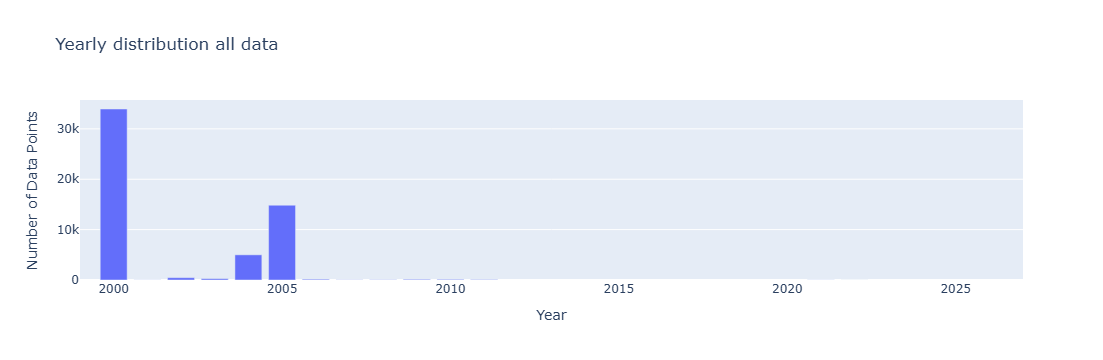

In [3]:
year_test=wod.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

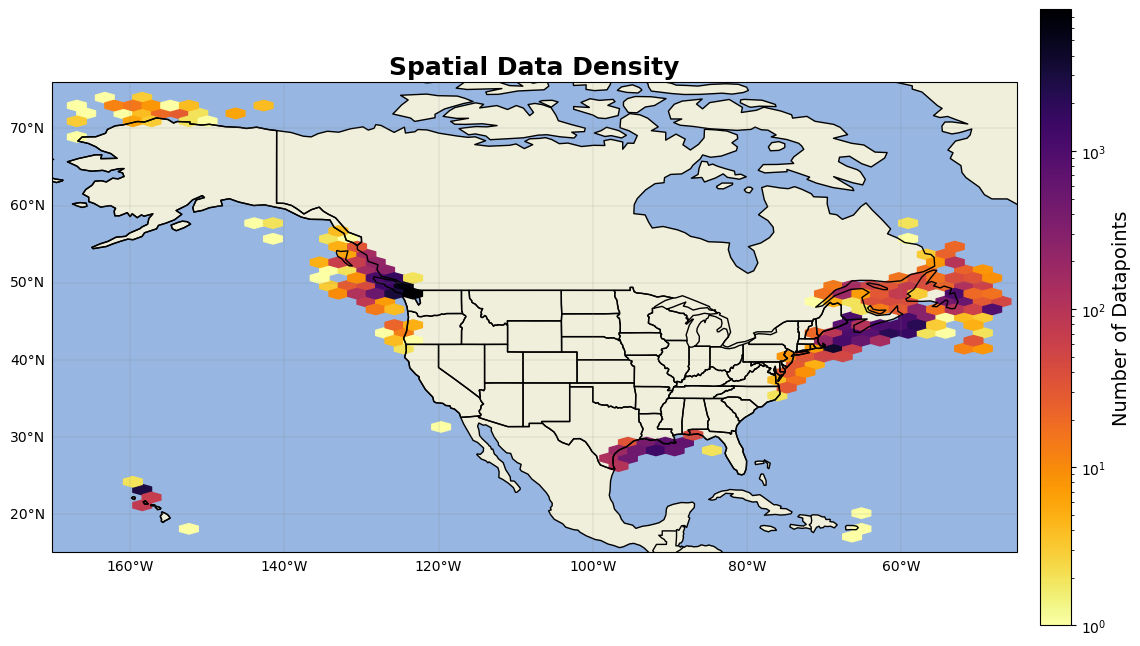

In [6]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=50, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()